In [91]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chisquare
from scipy import stats
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

In [5]:
web_df = pd.read_csv("data-files/web_page_data.csv")
sati_df = pd.read_csv("data-files/satisfaction.csv")

print(web_df.head())
print(sati_df.head())


     Page  Time
0  Page A  0.21
1  Page B  2.53
2  Page A  0.35
3  Page B  0.71
4  Page A  0.67
   Color  Satisfaction    ID
0  Black           0.9  ID_1
1    Red           2.3  ID_2
2  White           2.9  ID_3
3  Black           1.7  ID_4
4  White           3.2  ID_5


-1.1237042154424823 0.26901024363926024
→ 데이터의 유의미한 차이가 있습니다.
1.2633333333333332 1.62


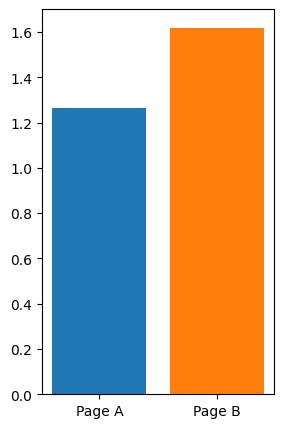

In [99]:
groupA = web_df[web_df["Page"] == "Page A"]["Time"]
groupB = web_df[web_df["Page"] == "Page B"]["Time"]

pt_stat, p_value = stats.ttest_ind(groupA, groupB)

print(pt_stat, p_value)

if p_value < 0.05:
    print("→ 데이터의 유의미한 차이가 있지 않습니다.")
else:
    print("→ 데이터의 유의미한 차이가 있습니다.")

print(groupA.mean(), groupB.mean())
plt.figure(figsize=(3, 5))
plt.bar(x='Page A', height=groupA.mean(), align='center')
plt.bar(x='Page B', height=groupB.mean(), align='center')
plt.show()


82.60327063615682 7.810636453305109e-21
→ 데이터의 유의미한 차이가 있습니다.
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
 Black    Red     0.04 0.9496 -0.2714 0.3514  False
 Black  White   1.4733    0.0  1.1619 1.7847   True
   Red  White   1.4333    0.0  1.1219 1.7447   True
---------------------------------------------------


<BarContainer object of 1 artists>

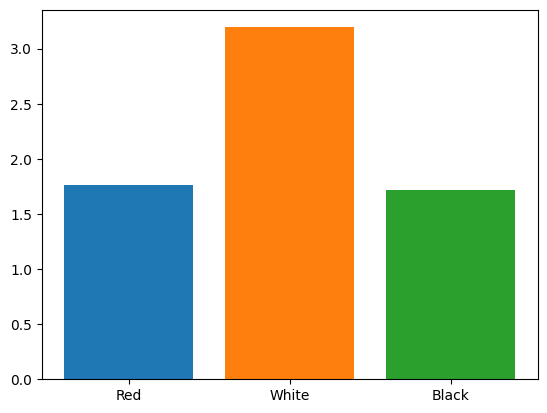

In [101]:
red = sati_df[sati_df["Color"] == "Red"]["Satisfaction"]
white = sati_df[sati_df["Color"] == "White"]["Satisfaction"]
black = sati_df[sati_df["Color"] == "Black"]["Satisfaction"]

f_stat, p_value = f_oneway(red, white, black)

print(f_stat, p_value)
if p_value < 0.05:
    print("→ 데이터의 유의미한 차이가 있습니다.")
else:
    print("→ 데이터의 유의미한 차이가 있지 않습니다.")


tukey = pairwise_tukeyhsd(endog=sati_df["Satisfaction"], groups=sati_df["Color"], alpha=0.05)
print(tukey.summary())


anova_lm(ols("Satisfaction ~ Color", sati_df).fit())


plt.bar(x='Red', height=red.mean(), align='center')
plt.bar(x='White', height=white.mean(), align='center')
plt.bar(x='Black', height=black.mean(), align='center')

